In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, CategoricalNB, BernoulliNB
import time
from sklearn.metrics import log_loss

In [20]:
# Problem 1
df1 = pd.read_csv('HealthProb1.csv')

# get explanatory and response variables separate
X1 = df1.drop(columns=['HealthCondition'])
y1 = df1['HealthCondition']

# 3.1, first split into training and validation
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, test_size=0.2, random_state = 5104)
df1_train = X1_train.copy()
df1_train['HealthCondition'] = y1_train
df1_val = X1_val.copy()
df1_val['HealthCondition'] = y1_val

df1_train.to_csv('Prob1_train.csv', index=False)
df1_val.to_csv('Prob1_val.csv', index=False)

for alpha value: 0, average recall metric measure value among the k=5 folds was 0.7053537533655276
for alpha value: 0.005, average recall metric measure value among the k=5 folds was 0.9052725189995
for alpha value: 0.01, average recall metric measure value among the k=5 folds was 0.8290184732489276
for alpha value: 0.015, average recall metric measure value among the k=5 folds was 0.8290184732489276
for alpha value: 0.02, average recall metric measure value among the k=5 folds was 0.8290184732489276
[0.7053537533655276, 0.9052725189995, 0.8290184732489276, 0.8290184732489276, 0.8290184732489276]
Best hyperparameter value was ccp_alpha = 0.005 with performance metric value of 0.9052725189995
Runtime: 77.83063101768494


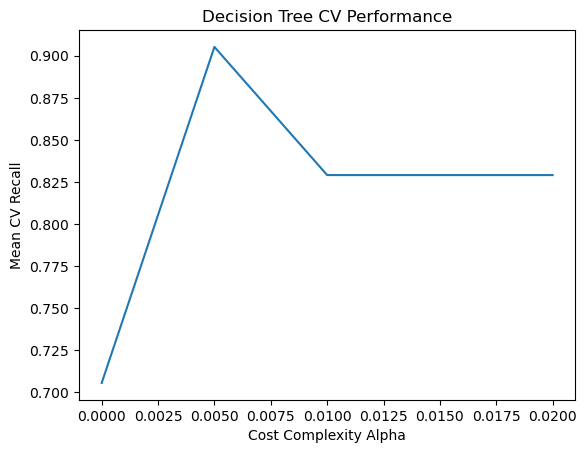

In [6]:
# Problem 1 - Decision Tree

ccp_alpha_vals = [0, 0.005, 0.010, 0.015, 0.020]

startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5104)
cv_means = []

for alpha in ccp_alpha_vals:
    dtc1 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=alpha, random_state=5104)
    scores = cross_val_score(dtc1, X1_train, y1_train, cv=kf, scoring='recall')
    # using recall as performance metric for each model because the cost of a false negative is higher than overall accuracy or a false positive
    # since false negative would mean potentially leaving a patient at risk of a health condition alone/untreated
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average recall metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was ccp_alpha = ' + str(ccp_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(ccp_alpha_vals, cv_means)
plt.xlabel('Cost Complexity Alpha')
plt.ylabel('Mean CV Recall')
plt.title('Decision Tree CV Performance')
plt.show()

folds done
for alpha value: 1e-05, average negative logloss metric measure value among the k=5 folds was -0.513425128659736
for alpha value: 0.0001, average negative logloss metric measure value among the k=5 folds was -0.5138237361167954
for alpha value: 0.001, average negative logloss metric measure value among the k=5 folds was -0.5138818334150875
for alpha value: 0.01, average negative logloss metric measure value among the k=5 folds was -0.5131208899955437
for alpha value: 0.1, average negative logloss metric measure value among the k=5 folds was -0.5141387480320841
[-0.513425128659736, -0.5138237361167954, -0.5138818334150875, -0.5131208899955437, -0.5141387480320841]
Best hyperparameter value was alpha = 0.01 with performance metric value of -0.5131208899955437
Runtime: 355.2096209526062


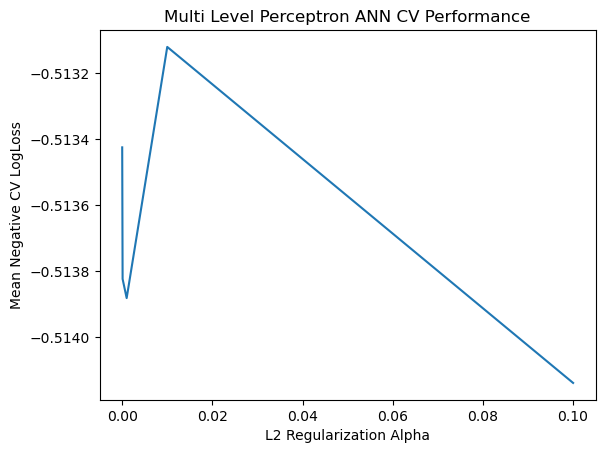

In [3]:
# Problem 1 - ANN

alpha_vals =  [0.00001, 0.0001, 0.001, 0.01, 0.1]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for alpha in alpha_vals:
    ann1 = MLPClassifier(activation = 'relu', alpha=alpha, random_state=5104, max_iter = 200)
    scores = cross_val_score(ann1, X1_train, y1_train, cv=kf, scoring='neg_log_loss')
    # using logloss/cross entropy loss as performance metric
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average negative logloss metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was alpha = ' + str(alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(alpha_vals, cv_means)
plt.xlabel('L2 Regularization Alpha')
plt.ylabel('Mean Negative CV LogLoss')
plt.title('Multi Level Perceptron ANN CV Performance')
plt.show()

alpha=0.0001, mean neg log loss=0.6236
for smoothing alpha value: 0.0001, average accuracy metric measure value among the k=5 folds was 0.6235562574460538
alpha=0.001, mean neg log loss=0.6236
for smoothing alpha value: 0.001, average accuracy metric measure value among the k=5 folds was 0.6235562574460538
alpha=0.01, mean neg log loss=0.6236
for smoothing alpha value: 0.01, average accuracy metric measure value among the k=5 folds was 0.6235562574460538
alpha=0.1, mean neg log loss=0.6236
for smoothing alpha value: 0.1, average accuracy metric measure value among the k=5 folds was 0.6235562574460538
alpha=0.5, mean neg log loss=0.6235
for smoothing alpha value: 0.5, average accuracy metric measure value among the k=5 folds was 0.6235464025592616
alpha=1, mean neg log loss=0.6235
for smoothing alpha value: 1, average accuracy metric measure value among the k=5 folds was 0.6235365476724697
alpha=5, mean neg log loss=0.6235
for smoothing alpha value: 5, average accuracy metric measure va

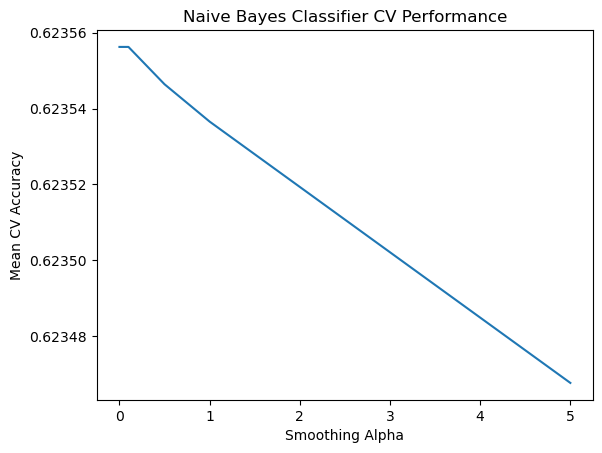

In [37]:
# Problem 1 - Naive Bayes Classifier

smoothing_alpha_vals =  [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5]

binary_vars = ['CholCheck', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

cat_vars = ['Age', 'Education', 'Income', 'GenHlth']

num_vars = ['BMI', 'MentHlth', 'PhysHlth']

X1_train_cat = X1_train[cat_vars]
X1_train_num = X1_train[num_vars]
X1_train_bin = X1_train[binary_vars]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5103)

cv_means = []
startTime = time.time()

for alpha in smoothing_alpha_vals:
    fold_scores = []
    
    for train_idx, test_idx in kf.split(X1_train, y1_train):

        # manually doing k folds bc idk how to use cross_val_score when combining results from 3 different estimators
        # split into separate training and test folds for cat, num and bin variables
        X_cat_tr = X1_train_cat.iloc[train_idx]
        X_cat_te = X1_train_cat.iloc[test_idx]
        
        X_num_tr = X1_train_num.iloc[train_idx]
        X_num_te = X1_train_num.iloc[test_idx]
        
        X_bin_tr = X1_train_bin.iloc[train_idx]
        X_bin_te = X1_train_bin.iloc[test_idx]
        
        y_tr = y1_train.iloc[train_idx]
        y_te = y1_train.iloc[test_idx]
        
        # models
        nbc = CategoricalNB(alpha=alpha)
        nbm = MultinomialNB(alpha=alpha)
        nbb = BernoulliNB(alpha=alpha)
        
        nbc.fit(X_cat_tr, y_tr)
        nbm.fit(X_num_tr, y_tr)
        nbb.fit(X_bin_tr, y_tr)
        
        # Use log probs in order to stop vals from getting to small at first
        log_prob_cat = nbc.predict_log_proba(X_cat_te)
        log_prob_num = nbm.predict_log_proba(X_num_te)
        log_prob_bin = nbb.predict_log_proba(X_bin_te)
        log_probs = log_prob_cat + log_prob_num + log_prob_bin

        # get performance metrics
        y_pred = np.argmax(log_probs, axis=1)
        acc = accuracy_score(y_te, y_pred)
        fold_scores.append(acc)
    
    mean_score = np.mean(fold_scores)
    cv_means.append(mean_score)
    
    print(f"alpha={alpha}, mean neg log loss={mean_score:.4f}")
    print('for smoothing alpha value: ' + str(alpha)+', average accuracy metric measure value among the k=5 folds was '+str(mean_score))


endTime = time.time()
runTime = endTime - startTime

best_index = np.argmax(cv_means)

print('Best hyperparameter value was alpha = ' + str(smoothing_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(smoothing_alpha_vals, cv_means)
plt.xlabel('Smoothing Alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('Naive Bayes Classifier CV Performance')
plt.show()

folds done
for number of trees: 25, average recall metric measure value among the k=5 folds was 0.8131755171885366
for number of trees: 50, average recall metric measure value among the k=5 folds was 0.8150371179483097
for number of trees: 100, average recall metric measure value among the k=5 folds was 0.8191608282104236
for number of trees: 200, average recall metric measure value among the k=5 folds was 0.8212423300106565
for number of trees: 300, average recall metric measure value among the k=5 folds was 0.822844688577119
[0.8131755171885366, 0.8150371179483097, 0.8191608282104236, 0.8212423300106565, 0.822844688577119]
Best hyperparameter value was number of trees = 300 with performance metric value of 0.822844688577119
Runtime: 374.14433884620667


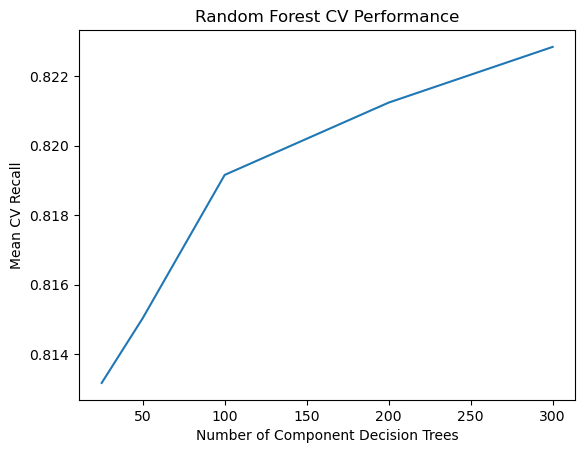

In [4]:
# Problem 1 - Random Forest

num_trees_vals = [25, 50, 100, 200, 300]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for tree_num in num_trees_vals:
    rfc1 = RandomForestClassifier(criterion = 'gini', n_estimators = tree_num)
    scores = cross_val_score(rfc1, X1_train, y1_train, cv=kf, scoring='recall')
    # using recall as performance metric (same reasoning as that for decision tree)
    cv_means.append(np.mean(scores))
    print('for number of trees: ' + str(tree_num)+', average recall metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was number of trees = ' + str(num_trees_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(num_trees_vals, cv_means)
plt.xlabel('Number of Component Decision Trees')
plt.ylabel('Mean CV Recall')
plt.title('Random Forest CV Performance')
plt.show()

In [5]:
# Problem 2
df2 = pd.read_csv('HealthProb2.csv')

# get explanatory and response variables separate
X2 = df2.drop(columns=['RiskLevel'])
y2 = df2['RiskLevel']

# 4.1, first split into training and validation
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.2, random_state = 5104)
df2_train = X2_train.copy()
df2_train['RiskLevel'] = y2_train
df2_val = X2_val.copy()
df2_val['RiskLevel'] = y2_val

df2_train.to_csv('Prob2_train.csv', index=False)
df2_val.to_csv('Prob2_val.csv', index=False)

for alpha value: 0, average accuracy metric measure value among the k=5 folds was 0.5168273147402866
for alpha value: 0.005, average accuracy metric measure value among the k=5 folds was 0.588093267408087
for alpha value: 0.01, average accuracy metric measure value among the k=5 folds was 0.5855556340591501
for alpha value: 0.015, average accuracy metric measure value among the k=5 folds was 0.5855556340591501
for alpha value: 0.02, average accuracy metric measure value among the k=5 folds was 0.5855556340591501
[0.5168273147402866, 0.588093267408087, 0.5855556340591501, 0.5855556340591501, 0.5855556340591501]
Best hyperparameter value was ccp_alpha = 0.005 with performance metric value of 0.588093267408087
Runtime: 144.0907518863678


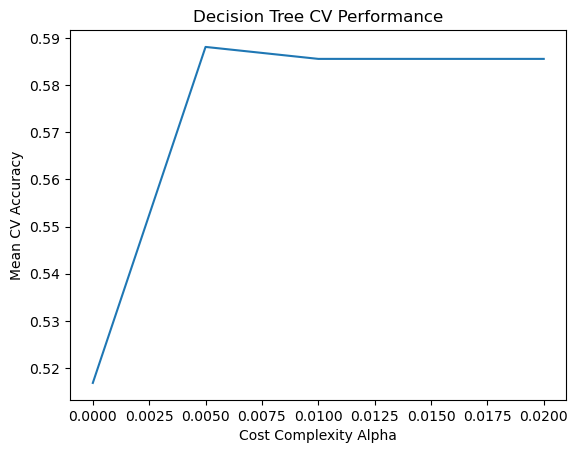

In [7]:
# Problem 2 - Decision Tree

ccp_alpha_vals = [0, 0.005, 0.010, 0.015, 0.020]

startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5104)
cv_means = []

for alpha in ccp_alpha_vals:
    dtc2 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=alpha, random_state=5104)
    scores = cross_val_score(dtc2, X2_train, y2_train, cv=kf, scoring='accuracy')
    # using accuracy instead of recall since we don't only have a positive and negative class anymore
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was ccp_alpha = ' + str(ccp_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(ccp_alpha_vals, cv_means)
plt.xlabel('Cost Complexity Alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('Decision Tree CV Performance')
plt.show()

folds done
for alpha value: 1e-05, average negative logloss metric measure value among the k=5 folds was -0.7843986026828857
for alpha value: 0.0001, average negative logloss metric measure value among the k=5 folds was -0.7840161226784288
for alpha value: 0.001, average negative logloss metric measure value among the k=5 folds was -0.7818664307078425
for alpha value: 0.01, average negative logloss metric measure value among the k=5 folds was -0.7835522860854515
for alpha value: 0.1, average negative logloss metric measure value among the k=5 folds was -0.7847307143389479
[-0.7843986026828857, -0.7840161226784288, -0.7818664307078425, -0.7835522860854515, -0.7847307143389479]
Best hyperparameter value was alpha = 0.001 with performance metric value of -0.7818664307078425
Runtime: 401.5748620033264


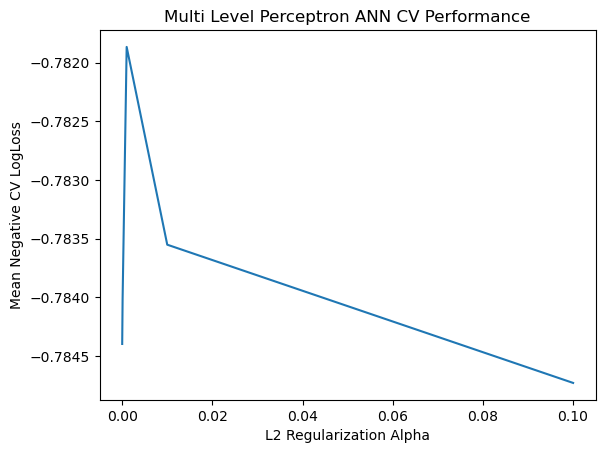

In [8]:
# Problem 2 - ANN

alpha_vals =  [0.00001, 0.0001, 0.001, 0.01, 0.1]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for alpha in alpha_vals:
    ann2 = MLPClassifier(activation = 'relu', alpha=alpha, random_state=5104, max_iter = 200)
    scores = cross_val_score(ann2, X2_train, y2_train, cv=kf, scoring='neg_log_loss')
    # using logloss/cross entropy loss as performance metric
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average negative logloss metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was alpha = ' + str(alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(alpha_vals, cv_means)
plt.xlabel('L2 Regularization Alpha')
plt.ylabel('Mean Negative CV LogLoss')
plt.title('Multi Level Perceptron ANN CV Performance')
plt.show()

alpha=0.0001, mean neg log loss=0.5057
for smoothing alpha value: 0.0001, average accuracy metric measure value among the k=5 folds was 0.505656745202492
alpha=0.001, mean neg log loss=0.5057
for smoothing alpha value: 0.001, average accuracy metric measure value among the k=5 folds was 0.505656745202492
alpha=0.01, mean neg log loss=0.5057
for smoothing alpha value: 0.01, average accuracy metric measure value among the k=5 folds was 0.5056616727672895
alpha=0.1, mean neg log loss=0.5057
for smoothing alpha value: 0.1, average accuracy metric measure value among the k=5 folds was 0.5056567453238935
alpha=0.5, mean neg log loss=0.5057
for smoothing alpha value: 0.5, average accuracy metric measure value among the k=5 folds was 0.5056518178804975
alpha=1, mean neg log loss=0.5056
for smoothing alpha value: 1, average accuracy metric measure value among the k=5 folds was 0.5056419627509026
alpha=5, mean neg log loss=0.5056
for smoothing alpha value: 5, average accuracy metric measure valu

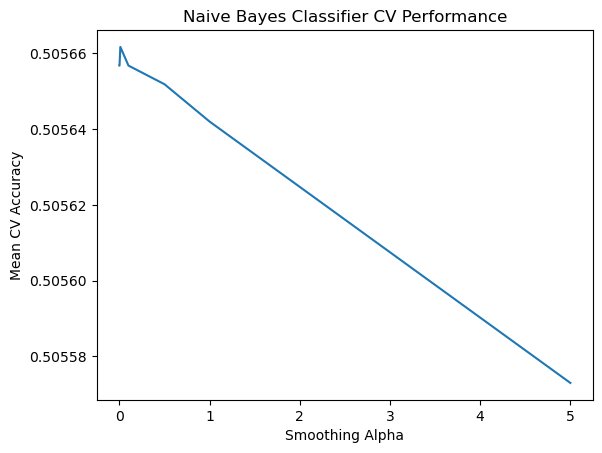

In [36]:
# Problem 1 - Naive Bayes Classifier

smoothing_alpha_vals =  [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5]

binary_vars = ['CholCheck', 'Smoker', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

cat_vars = ['Age', 'Education', 'Income', 'GenHlth']

num_vars = ['BMI', 'MentHlth', 'PhysHlth']

X2_train_cat = X2_train[cat_vars]
X2_train_num = X2_train[num_vars]
X2_train_bin = X2_train[binary_vars]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5103)

cv_means = []
startTime = time.time()

for alpha in smoothing_alpha_vals:
    fold_scores = []
    
    for train_idx, test_idx in kf.split(X2_train, y2_train):

        # manually doing k folds bc idk how to use cross_val_score when combining results from 3 different estimators
        # split into separate training and test folds for cat, num and bin variables
        X_cat_tr = X2_train_cat.iloc[train_idx]
        X_cat_te = X2_train_cat.iloc[test_idx]
        
        X_num_tr = X2_train_num.iloc[train_idx]
        X_num_te = X2_train_num.iloc[test_idx]
        
        X_bin_tr = X2_train_bin.iloc[train_idx]
        X_bin_te = X2_train_bin.iloc[test_idx]
        
        y_tr = y2_train.iloc[train_idx]
        y_te = y2_train.iloc[test_idx]
        
        # models
        nbc = CategoricalNB(alpha=alpha)
        nbm = MultinomialNB(alpha=alpha)
        nbb = BernoulliNB(alpha=alpha)
        
        nbc.fit(X_cat_tr, y_tr)
        nbm.fit(X_num_tr, y_tr)
        nbb.fit(X_bin_tr, y_tr)
        
        # Use log probs in order to stop vals from getting to small at first
        log_prob_cat = nbc.predict_log_proba(X_cat_te)
        log_prob_num = nbm.predict_log_proba(X_num_te)
        log_prob_bin = nbb.predict_log_proba(X_bin_te)
        log_probs = log_prob_cat + log_prob_num + log_prob_bin

        # get performance metrics
        y_pred = np.argmax(log_probs, axis=1)
        acc = accuracy_score(y_te, y_pred)
        fold_scores.append(acc)
    
    mean_score = np.mean(fold_scores)
    cv_means.append(mean_score)
    
    print(f"alpha={alpha}, mean neg log loss={mean_score:.4f}")
    print('for smoothing alpha value: ' + str(alpha)+', average accuracy metric measure value among the k=5 folds was '+str(mean_score))


endTime = time.time()
runTime = endTime - startTime

best_index = np.argmax(cv_means)

print('Best hyperparameter value was alpha = ' + str(smoothing_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(smoothing_alpha_vals, cv_means)
plt.xlabel('Smoothing Alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('Naive Bayes Classifier CV Performance')
plt.show()

folds done
for number of trees: 25, average accuracy metric measure value among the k=5 folds was 0.5867875017066317
for number of trees: 50, average accuracy metric measure value among the k=5 folds was 0.592394967497703
for number of trees: 100, average accuracy metric measure value among the k=5 folds was 0.5950410110356303
for number of trees: 200, average accuracy metric measure value among the k=5 folds was 0.596563597479271
for number of trees: 300, average accuracy metric measure value among the k=5 folds was 0.5980024144715443
[0.5867875017066317, 0.592394967497703, 0.5950410110356303, 0.596563597479271, 0.5980024144715443]
Best hyperparameter value was number of trees = 300 with performance metric value of 0.5980024144715443
Runtime: 408.4678888320923


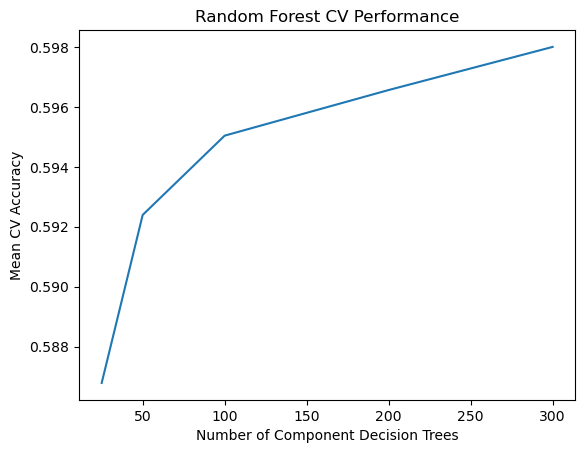

In [9]:
# Problem 2 - Random Forest

num_trees_vals = [25, 50, 100, 200, 300]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for tree_num in num_trees_vals:
    rfc2 = RandomForestClassifier(criterion = 'gini', n_estimators = tree_num)
    scores = cross_val_score(rfc2, X2_train, y2_train, cv=kf, scoring='accuracy')
    # using recall as performance metric (same reasoning as that for decision tree)
    cv_means.append(np.mean(scores))
    print('for number of trees: ' + str(tree_num)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was number of trees = ' + str(num_trees_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(num_trees_vals, cv_means)
plt.xlabel('Number of Component Decision Trees')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest CV Performance')
plt.show()